# [제출본] 쓰리핑즈(3조) 코드

## [데이터 파악] 파일 불러오기 및 상세 데이터 조회

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows -> 한글로 쓰면 인코딩 깨지는걸 방지해줌.
plt.rcParams['font.family'] = 'AppleGothic' # For MacOS

%matplotlib inline

df = pd.read_csv('차량 연비 데이터(2002~2022).csv')
df

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,CITY (L/100 km),HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22551,2022,Volvo,XC40 T5 AWD,SUV: Small,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
22552,2022,Volvo,XC60 B5 AWD,SUV: Small,2.0,4,AS8,Z,10.5,8.1,9.4,30,219
22553,2022,Volvo,XC60 B6 AWD,SUV: Small,2.0,4,AS8,Z,11.0,8.7,9.9,29,232
22554,2022,Volvo,XC90 T5 AWD,SUV: Standard,2.0,4,AS8,Z,11.5,8.4,10.1,28,236


In [17]:
df.shape

(22556, 13)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             22556 non-null  int64  
 1   MAKE             22556 non-null  object 
 2   MODEL            22556 non-null  object 
 3   VEHICLE CLASS    22556 non-null  object 
 4   ENGINE SIZE      22556 non-null  float64
 5   CYLINDERS        22556 non-null  int64  
 6   TRANSMISSION     22556 non-null  object 
 7   FUEL             22556 non-null  object 
 8   CITY (L/100 km)  22556 non-null  float64
 9   HWY (L/100 km)   22556 non-null  float64
 10  COMB (L/100 km)  22556 non-null  float64
 11  COMB (mpg)       22556 non-null  int64  
 12  EMISSIONS        22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


In [19]:
# 기술통계 요약 
df.describe()

,YEAR,ENGINE SIZE,CYLINDERS,CITY (L/100 km),HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
count,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000
mean,2011.554442,3.356646,5.854141,12.763513,8.919126,11.034341,27.374534,250.068452
std,6.298269,1.335425,1.819597,3.500999,2.274764,2.910920,7.376982,59.355276
min,2000.000000,0.800000,2.000000,3.500000,3.200000,3.600000,11.000000,83.000000
25%,2006.000000,2.300000,4.000000,10.400000,7.300000,9.100000,22.000000,209.000000
50%,2012.000000,3.000000,6.000000,12.300000,8.400000,10.600000,27.000000,243.000000
75%,2017.000000,4.200000,8.000000,14.725000,10.200000,12.700000,31.000000,288.000000
max,2022.000000,8.400000,16.000000,30.600000,20.900000,26.100000,78.000000,608.000000


## [전처리] 결측치 확인, 중복 제거, 이상치 제거, 단위 변환 등

### 결측치 확인

In [20]:
#결측치 없음
df.isna().sum()

YEAR               0
MAKE               0
MODEL              0
VEHICLE CLASS      0
ENGINE SIZE        0
CYLINDERS          0
TRANSMISSION       0
FUEL               0
CITY (L/100 km)    0
HWY (L/100 km)     0
COMB (L/100 km)    0
COMB (mpg)         0
EMISSIONS          0
dtype: int64

### 연비 단위 변환

In [21]:
# 연비 단위 변환
clean_df = df.copy()
clean_df["COMB_km_per_l"] = 100 / clean_df["COMB (L/100 km)"] 
clean_df

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,CITY (L/100 km),HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS,COMB_km_per_l
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186,12.345679
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175,13.157895
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230,10.000000
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264,8.695652
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198,11.627907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22551,2022,Volvo,XC40 T5 AWD,SUV: Small,2.0,4,AS8,Z,10.7,7.7,9.4,30,219,10.638298
22552,2022,Volvo,XC60 B5 AWD,SUV: Small,2.0,4,AS8,Z,10.5,8.1,9.4,30,219,10.638298
22553,2022,Volvo,XC60 B6 AWD,SUV: Small,2.0,4,AS8,Z,11.0,8.7,9.9,29,232,10.101010
22554,2022,Volvo,XC90 T5 AWD,SUV: Standard,2.0,4,AS8,Z,11.5,8.4,10.1,28,236,9.900990


### 차종 이름 정리

In [22]:
# 중복 차종 하나로 통일, 이름 형식도 최대한 통일(언더바)
clean_df = clean_df.copy()
clean_df["VEHICLE CLASS"] = clean_df["VEHICLE CLASS"].str.upper() 
clean_df["VEHICLE CLASS"] = clean_df["VEHICLE CLASS"].replace({
    'STATION WAGON - SMALL' : 'STATION WAGON_SMALL',
    'STATION WAGON: SMALL' : 'STATION WAGON_SMALL',
    'STATION WAGON - MID-SIZE' : 'STATION WAGON_MID',
    'STATION WAGON: MID-SIZE' : 'STATION WAGON_MID',
    'SUV - STANDARD' : 'SUV_STANDARD',
    'SUV: STANDARD' : 'SUV_STANDARD',
    'SUV - SMALL' : 'SUV_SMALL',
    'SUV: SMALL' : 'SUV_SMALL',
    'VAN - CARGO' : 'VAN_CARGO',
    'VAN - PASSENGER' : 'VAN_PASSENGER',
    'VAN: PASSENGER' : 'VAN_PASSENGER',
    'PICKUP TRUCK - STANDARD' : 'PICKUP TRUCK_STANDARD',
    'PICKUP TRUCK: STANDARD' : 'PICKUP TRUCK_STANDARD',
    'PICKUP TRUCK - SMALL' : 'PICKUP TRUCK_SMALL',
    'PICKUP TRUCK: SMALL' : 'PICKUP TRUCK_SMALL',
})
clean_df['VEHICLE CLASS'].value_counts()

VEHICLE CLASS
COMPACT                    3127
MID-SIZE                   2960
SUV                        2640
PICKUP TRUCK_STANDARD      2204
SUBCOMPACT                 2010
SUV_SMALL                  1756
FULL-SIZE                  1503
TWO-SEATER                 1312
SUV_STANDARD               1122
MINICOMPACT                 994
STATION WAGON_SMALL         877
PICKUP TRUCK_SMALL          511
MINIVAN                     408
STATION WAGON_MID           387
VAN_CARGO                   332
VAN_PASSENGER               299
SPECIAL PURPOSE VEHICLE     114
Name: count, dtype: int64

### 중복 제거

In [23]:
# 중복제거(1개)
clean_df = clean_df.copy()
clean_df = clean_df.drop_duplicates()
clean_df

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,CITY (L/100 km),HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS,COMB_km_per_l
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186,12.345679
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175,13.157895
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230,10.000000
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264,8.695652
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198,11.627907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22551,2022,Volvo,XC40 T5 AWD,SUV_SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219,10.638298
22552,2022,Volvo,XC60 B5 AWD,SUV_SMALL,2.0,4,AS8,Z,10.5,8.1,9.4,30,219,10.638298
22553,2022,Volvo,XC60 B6 AWD,SUV_SMALL,2.0,4,AS8,Z,11.0,8.7,9.9,29,232,10.101010
22554,2022,Volvo,XC90 T5 AWD,SUV_STANDARD,2.0,4,AS8,Z,11.5,8.4,10.1,28,236,9.900990


### 이상치 정의 및 제거

In [24]:
# --- 이상치 정의 ---
# 실린더: 2, 16 → 이상치
clean_df = clean_df.copy()
bad_cyl = clean_df["CYLINDERS"].isin([2, 16])

# 차종: SPECIAL PURPOSE VEHICLE, TWO-SEATER → 이상치
bad_class = clean_df["VEHICLE CLASS"].isin(["SPECIAL PURPOSE VEHICLE", "TWO-SEATER"])

# 두 조건 중 하나라도 해당하면 이상치로 간주
outlier_mask = bad_cyl | bad_class

# --- 제거 전 통계 확인(선택) ---
print("총 행:", len(clean_df))
print("이상치 행 수:", outlier_mask.sum())
print("\n이상치 - CYLINDERS 분포:\n", clean_df.loc[bad_cyl, "CYLINDERS"].value_counts())
print("\n이상치 - VEHICLE CLASS 분포:\n", clean_df.loc[bad_class, "VEHICLE CLASS"].value_counts())

# --- 이상치 제거 & clean_df 갱신 ---
clean_df = clean_df.loc[~outlier_mask].reset_index(drop=True)

# --- 제거 후 확인 ---
print("\n이상치 제거 후 총 행:", len(clean_df))

총 행: 22555
이상치 행 수: 1442

이상치 - CYLINDERS 분포:
 CYLINDERS
2     16
16    12
Name: count, dtype: int64

이상치 - VEHICLE CLASS 분포:
 VEHICLE CLASS
TWO-SEATER                 1312
SPECIAL PURPOSE VEHICLE     114
Name: count, dtype: int64

이상치 제거 후 총 행: 21113


## [시각화] PPT에 삽입된 그래프 코드

### 1. 연비와 CO2 배출량의 관계

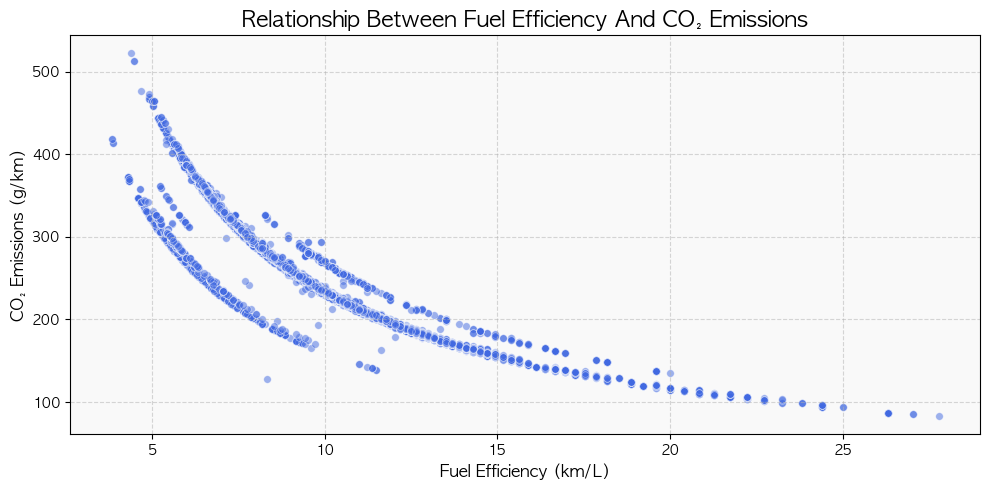

In [25]:
plt.figure(figsize=(10,5)) # figsize 통일

# 점 스타일
plt.scatter(
    clean_df["COMB_km_per_l"], clean_df["EMISSIONS"],
    alpha=0.5, #투명도 0.5
    s=30,  #점 크기 30
    c="royalblue",  #점 색은 파랑
    edgecolors="white",  #edgecolor white 점 테두리는 하양
    linewidth=0.5 # 선 두께는 0.5
)

# 제목 & 라벨 (영문)
plt.title("Relationship Between Fuel Efficiency And CO₂ Emissions", fontsize=16, fontweight="bold") #제목 크기 16, 볼드체
plt.xlabel("Fuel Efficiency (km/L)", fontsize=12, weight='bold') #x 라벨 크기 12
plt.ylabel("CO₂ Emissions (g/km)", fontsize=12, weight='bold') #y 라벨 크기 12

# 격자 추가 -- 격자 형식, 투명도 0.5
plt.grid(True, linestyle="--", alpha=0.5)

# 배경 스타일 -- 항상 회색으로
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

### 2. 엔진 크기와 실린더의 관계

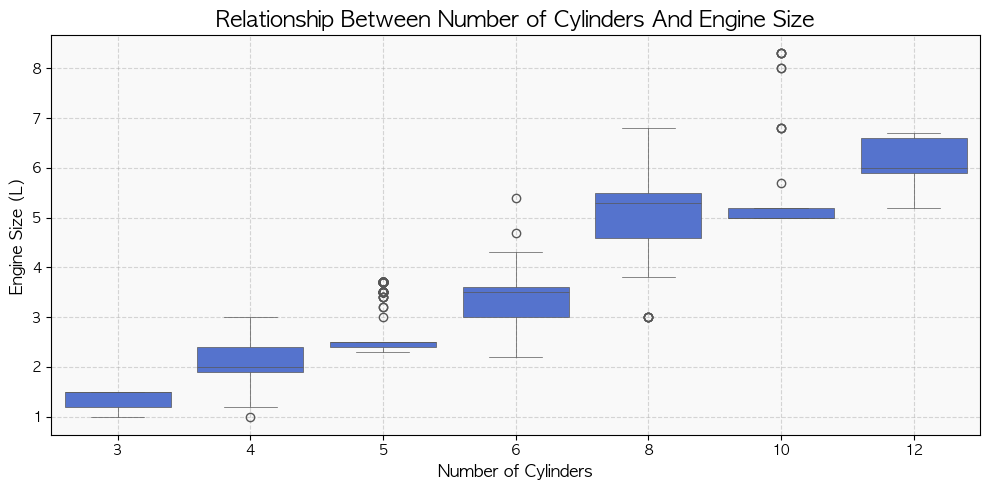

'\n산점도로도 만들어봤는데, 박스플롯이 더 낫다는 것을 간략하게 서술\n'

In [26]:
# Boxplot 그래프

plt.figure(figsize=(10, 5))

sns.boxplot(x="CYLINDERS", y="ENGINE SIZE", data=clean_df, color='royalblue', linewidth=0.5)

plt.title("Relationship Between Number of Cylinders And Engine Size", fontsize=16, fontweight="bold")
plt.xlabel("Number of Cylinders", fontsize=12, fontweight="bold")
plt.ylabel("Engine Size (L)", fontsize=12, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.5)

# 배경 스타일
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

"""
산점도로도 만들어봤는데, 박스플롯이 더 낫다는 것을 간략하게 서술
"""


### 3-1. 엔진 크기별 CO₂ 배출량

/var/folders/xr/h3sspt_54ygby4y5666yc_380000gn/T/ipykernel_2757/242005525.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


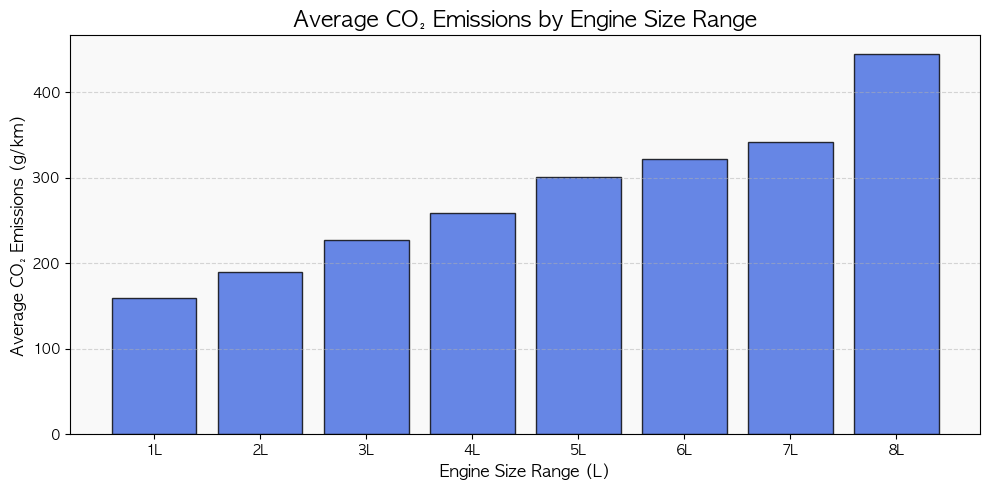

In [27]:
clean_df.loc[clean_df["ENGINE SIZE"] > 8, "ENGINE SIZE"] = 8  #8이상은 그냥 8로

# 엔진 크기 구간(bins)과 각 구간에 붙일 라벨(labels) 정의
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8]
labels = ["1L", "2L", "3L", "4L", "5L", "6L", "7L", "8L"]

# 새로운 컬럼 없이 groupby 안에서 pd.cut 사용
co2_by_engine_bin = (
    clean_df
    .groupby(
        pd.cut(
            clean_df["ENGINE SIZE"],
            bins=bins,
            labels=labels,
        )
    )["EMISSIONS"]
    .mean()
    .reset_index()
)

# 그래프 시각화
plt.figure(figsize=(10,5))
plt.bar(
    co2_by_engine_bin["ENGINE SIZE"],   # pd.cut 결과가 자동으로 "ENGINE SIZE"라는 이름 붙음
    co2_by_engine_bin["EMISSIONS"],
    color='royalblue',
    alpha=0.8, # 바 그래프는 투명도 0.8
    edgecolor='black'
)

# 그래프 제목과 축 레이블 설정
plt.title("Average CO₂ Emissions by Engine Size Range", fontsize=16, fontweight="bold")
plt.xlabel("Engine Size Range (L)", fontsize=12, fontweight='bold')
plt.ylabel("Average CO₂ Emissions (g/km)", fontsize=12, fontweight='bold')

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5) #투명도는 0.5
# 배경 스타일
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

### 3-2. 엔진 크기별 연비



/var/folders/xr/h3sspt_54ygby4y5666yc_380000gn/T/ipykernel_2757/3991124241.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


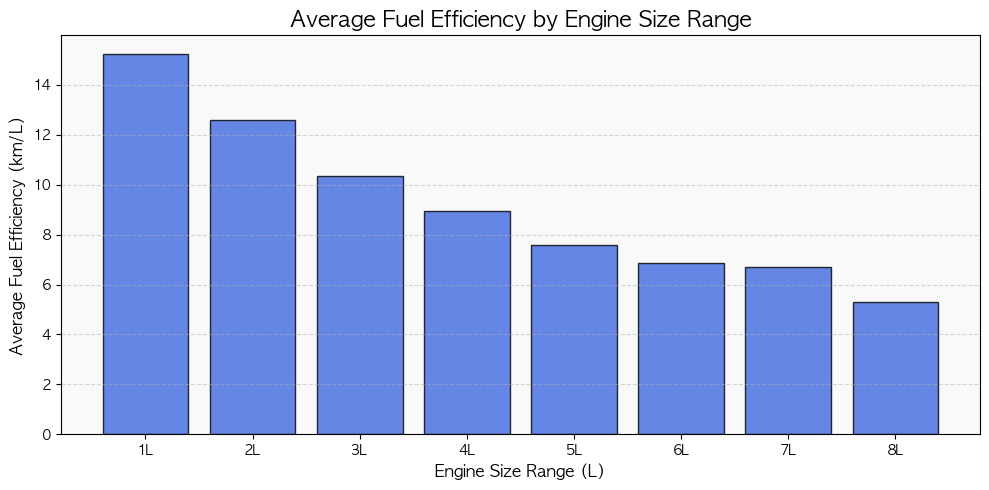

In [28]:
clean_df.loc[clean_df["ENGINE SIZE"] > 8, "ENGINE SIZE"] = 8

bins = [0, 1, 2, 3, 4, 5, 6, 7, 8]
labels = ["1L", "2L", "3L", "4L", "5L", "6L", "7L", "8L"]

# 여기서 pd.cut을 groupby 안에 직접 넣음 → 컬럼 추가 X
eff_by_engine_bin = (
    clean_df
    .groupby(
        pd.cut(
            clean_df["ENGINE SIZE"],
            bins=bins,
            labels=labels,
        )
    )["COMB_km_per_l"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(
    eff_by_engine_bin["ENGINE SIZE"],   # pd.cut 결과가 자동으로 "ENGINE SIZE"라는 이름 붙음
    eff_by_engine_bin["COMB_km_per_l"],
    color='royalblue',
    alpha=0.8, # 바 그래프는 투명도 0.8
    edgecolor='black'
)

plt.title("Average Fuel Efficiency by Engine Size Range", fontsize=16, fontweight="bold") ### 제목 바꿔놔야함
plt.xlabel("Engine Size Range (L)", fontsize=12, weight='bold') # 크기
plt.ylabel("Average Fuel Efficiency (km/L)", fontsize=12, weight='bold') # 조정
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5) #투명도 0.5

# 배경 스타일 -- 항상 회색으로
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

### 4-1. 차종별 CO₂ 배출량


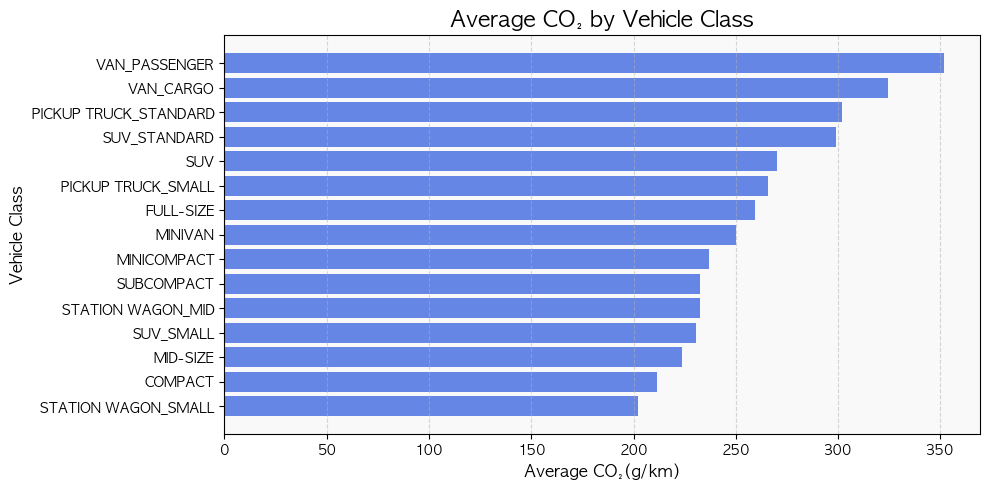

In [29]:
ov = (clean_df.groupby("VEHICLE CLASS")["EMISSIONS"].mean()
        .sort_values().round(2))

plt.figure(figsize=(10,5))
plt.barh(ov.index, ov.values, color='royalblue',alpha=0.8) #바는 0.8

plt.title("Average CO₂ by Vehicle Class", fontsize=16, fontweight="bold") #제목 16
plt.xlabel("Average CO₂(g/km)", fontsize=12, weight='bold') #x라벨 12
plt.ylabel("Vehicle Class", fontsize=12, weight='bold') #y라벨 12
plt.grid(axis="x", linestyle="--", alpha=0.5) #그리드 0.5

# 배경 스타일 -- 항상 회색으로
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

### 4-2. 차종별 연비


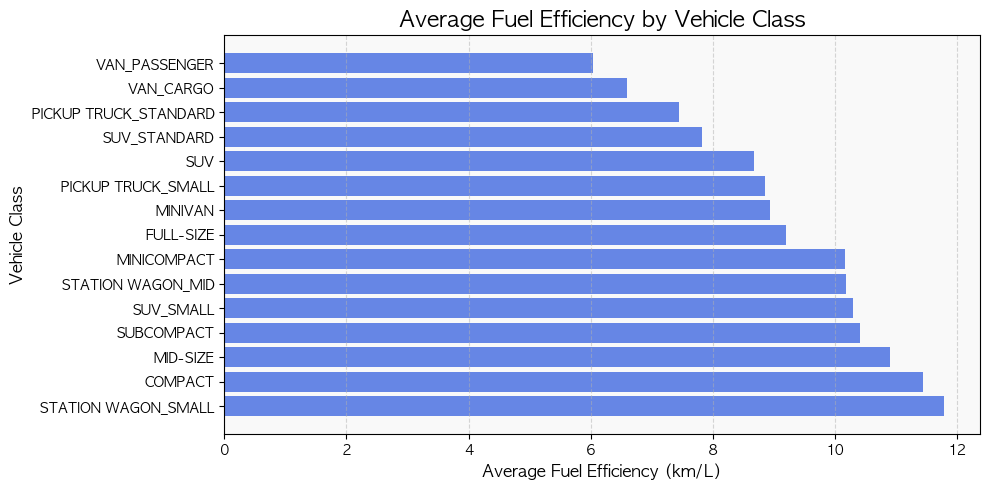

In [30]:
ov = (clean_df.groupby("VEHICLE CLASS")["COMB_km_per_l"].mean()
        .sort_values(ascending=False).round(2)) # sort 해서 값(평균 연비) 기준으로 내림차순

plt.figure(figsize=(10,5))
plt.barh(ov.index, ov.values, color="royalblue",alpha=0.8)


plt.title("Average Fuel Efficiency by Vehicle Class" , fontsize=16, fontweight="bold") #제목 16

plt.xlabel("Average Fuel Efficiency (km/L)" , fontsize=12, weight='bold') #x라벨 12
plt.ylabel("Vehicle Class", fontsize=12, weight='bold') #y라벨 12
plt.grid(axis="x", linestyle="--", alpha=0.5) #그리드 0.5

# 배경 스타일 -- 항상 회색으로
plt.gca().set_facecolor("#f9f9f9")


plt.tight_layout()
plt.show()

### 5-1. 연료별 CO₂ 배출량


/var/folders/xr/h3sspt_54ygby4y5666yc_380000gn/T/ipykernel_2757/1677579010.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


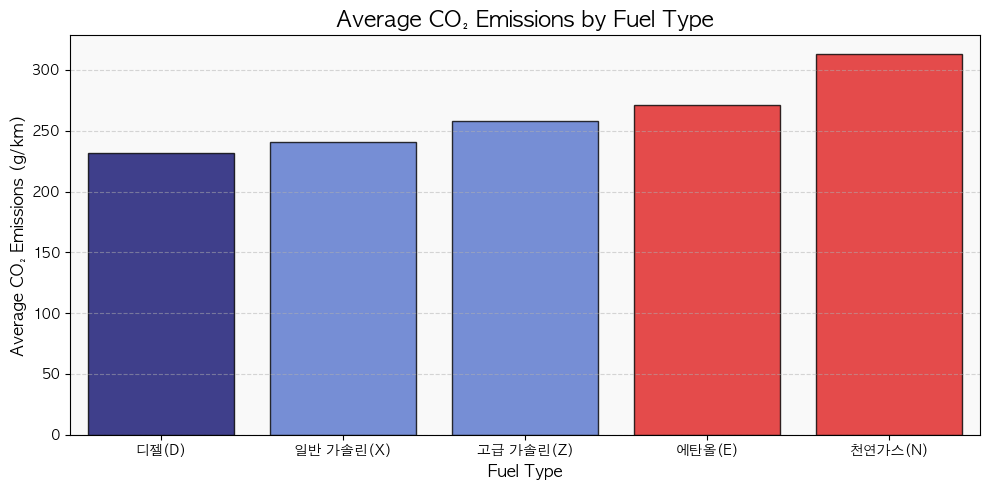

In [31]:
# 연료별 평균 CO₂ 배출량
co2_by_fuel = clean_df.groupby("FUEL")["EMISSIONS"].mean().sort_values()

plt.figure(figsize=(10,5))

# 사용자 정의 팔레트 (조건에 맞게 변경)
custom_colors = {
    'D': 'navy',         # 디젤 → 진한 파랑
    'X': 'royalblue',    # 일반 가솔린 → 파랑
    'Z': 'royalblue',    # 고급 가솔린 → 파랑
    'E': 'red',          # 에탄올 → 빨강
    'N': 'red'           # 천연가스 → 빨강
}

# 연료 순서에 맞춰 색상 리스트 생성
colors = [custom_colors[f] for f in co2_by_fuel.index]

sns.barplot(
    x=co2_by_fuel.index,
    y=co2_by_fuel.values,
    palette=colors,
    edgecolor='black',
    alpha=0.8
)


plt.title("Average CO₂ Emissions by Fuel Type", fontsize=16, fontweight="bold")
plt.xlabel("Fuel Type", fontsize=12, weight='bold')
plt.ylabel("Average CO₂ Emissions (g/km)", fontsize=12, weight='bold')

# x축 라벨 한글로 다시 지정
plt.xticks(
    ticks=[0,1,2,3,4],
    labels=['디젤(D)','일반 가솔린(X)','고급 가솔린(Z)','에탄올(E)','천연가스(N)']
)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_facecolor("#f9f9f9")  # 배경 연한 회색
plt.tight_layout()
plt.show()


### 5-2. 연료별 연비


/var/folders/xr/h3sspt_54ygby4y5666yc_380000gn/T/ipykernel_2757/2138056014.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


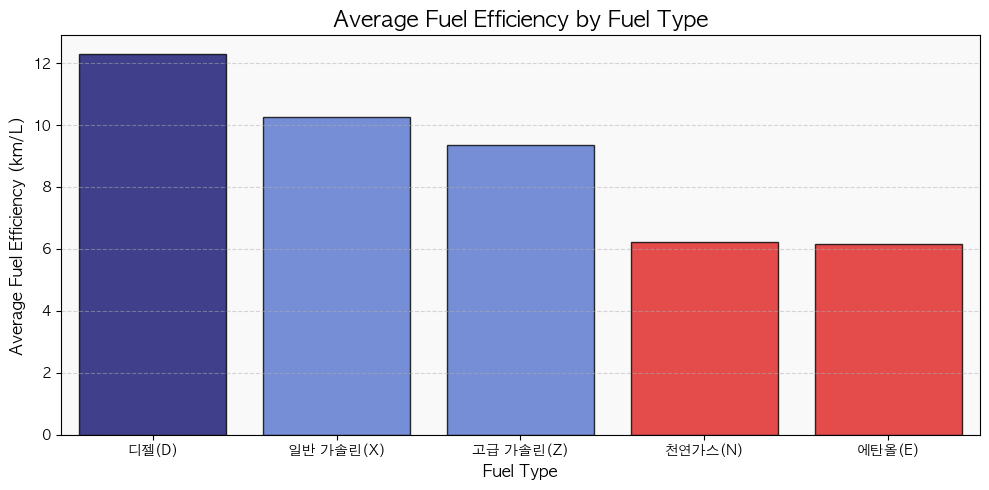

In [32]:
# 연료별 평균 연비 효율
fuel_eff_by_fuel = clean_df.groupby("FUEL")["COMB_km_per_l"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

# 요청에 맞는 색상 팔레트 지정
custom_colors = {
    'D': 'navy',        # 디젤
    'X': 'royalblue',   # 일반 가솔린
    'Z': 'royalblue',   # 고급 가솔린
    'E': 'red',         # 에탄올
    'N': 'red'          # 천연가스
}

# fuel_eff_by_fuel 순서에 맞춰 색상 리스트 생성
colors = [custom_colors[f] for f in fuel_eff_by_fuel.index]

sns.barplot(
    x=fuel_eff_by_fuel.index,
    y=fuel_eff_by_fuel.values,
    palette=colors,        # 리스트로 지정해야 순서 반영됨
    edgecolor='black',
    alpha=0.8
)

plt.title("Average Fuel Efficiency by Fuel Type", fontsize=16, fontweight="bold")
plt.xlabel("Fuel Type", fontsize=12, weight='bold')
plt.ylabel("Average Fuel Efficiency (km/L)", fontsize=12, weight='bold')

# x축 라벨 한글
plt.xticks(
    ticks=range(len(fuel_eff_by_fuel.index)),
    labels=['디젤(D)','일반 가솔린(X)','고급 가솔린(Z)','천연가스(N)','에탄올(E)']
)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_facecolor("#f9f9f9")  
plt.tight_layout()
plt.show()


### 6-1. 연도별 CO₂ 배출량


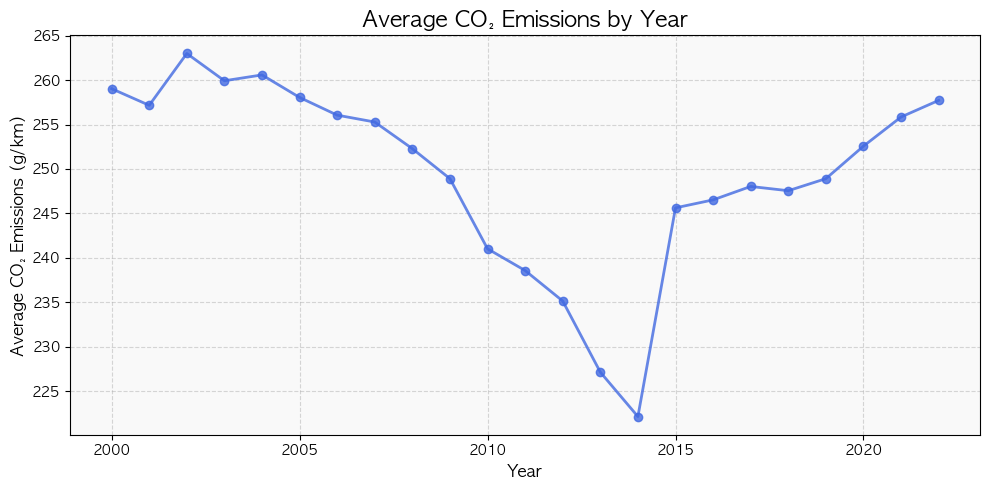

In [33]:
co2_by_year = clean_df.groupby("YEAR")["EMISSIONS"].mean()

plt.figure(figsize=(10,5))
plt.plot(
    co2_by_year.index,
    co2_by_year.values,
    marker="o",
    color="royalblue",
    linewidth=2,alpha=0.8 #선 그래프도 투명도는 0.8
    )

plt.title("Average CO₂ Emissions by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12, fontweight="bold")
plt.ylabel("Average CO₂ Emissions (g/km)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.gca().set_facecolor("#f9f9f9")  # 배경 연한 회색
plt.tight_layout()
plt.show()


### 6-2. 연도별 연비


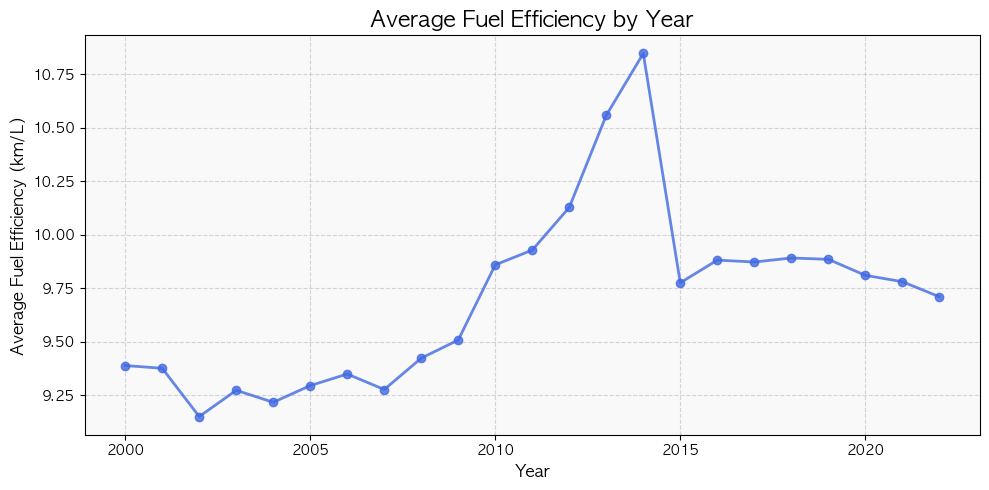

In [34]:
fuel_eff_by_year = clean_df.groupby("YEAR")["COMB_km_per_l"].mean()

plt.figure(figsize=(10,5))
plt.plot(
    fuel_eff_by_year.index,
    fuel_eff_by_year.values,
    marker="o",
    color="royalblue",
    linewidth=2,alpha=0.8
    )

plt.title("Average Fuel Efficiency by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Average Fuel Efficiency (km/L)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

plt.gca().set_facecolor("#f9f9f9")  # 배경 연한 회색
plt.tight_layout()
plt.show()

### 7-1. 2015년 이후 CO₂ 배출량 심화 분석




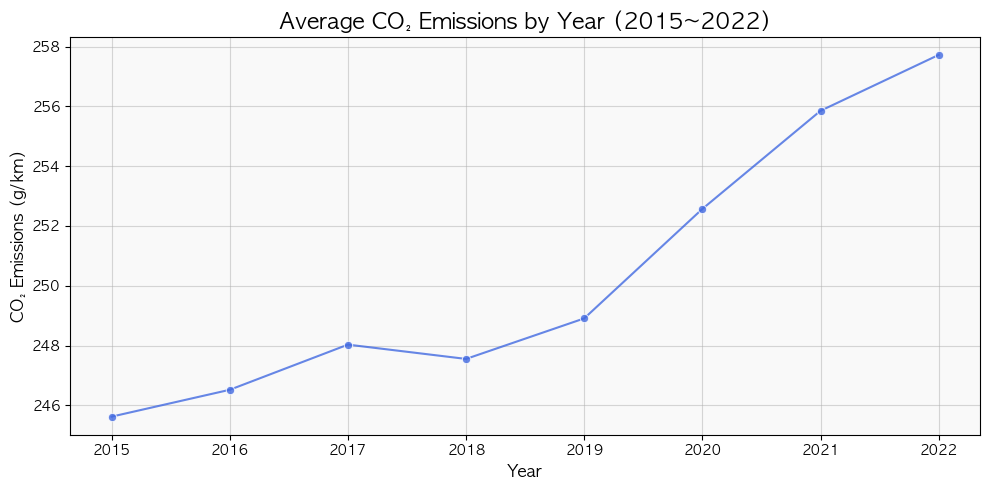

In [35]:
# CO₂ 배출량 (2015~2022)
df_after_2015 = clean_df[clean_df['YEAR'] >= 2015]
yearly_emissions = df_after_2015.groupby('YEAR')['EMISSIONS'].mean()

# 시각화
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_emissions.index, y=yearly_emissions.values,
             marker='o', color='royalblue', alpha=0.8) # 선 그래프이므로 0.8

plt.title("Average CO₂ Emissions by Year (2015~2022)", fontsize=16, weight='bold')
plt.xlabel("Year", fontsize=12, weight='bold')                 # ← X 라벨 12
plt.ylabel("CO₂ Emissions (g/km)", fontsize=12, weight='bold') # ← Y 라벨 12
plt.grid(True, alpha=0.5) #격자선은 0.5

plt.gca().set_facecolor("#f9f9f9")  # 배경 연한 회색
plt.tight_layout()
plt.show()


### 7-2. 2015년 이후 연비 심화 분석


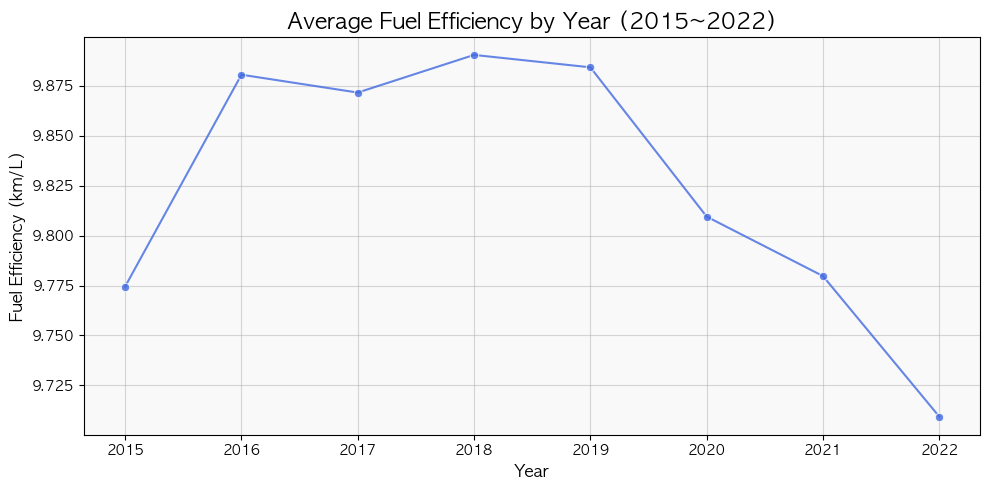

In [36]:
# 연비 (2015~2022)

df_after_2015 = clean_df[clean_df['YEAR'] >= 2015]
yearly_efficiency = df_after_2015.groupby('YEAR')["COMB_km_per_l"].mean()

# 시각화
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_efficiency.index, y=yearly_efficiency.values,
             marker='o', color='royalblue', alpha=0.8)

plt.title("Average Fuel Efficiency by Year (2015~2022)", fontsize=16, weight='bold')
plt.xlabel("Year", fontsize=12, weight='bold')         # ← 글씨 크기 & 굵기 조정
plt.ylabel("Fuel Efficiency (km/L)", fontsize=12, weight='bold')

plt.grid(True, alpha=0.5)

plt.gca().set_facecolor("#f9f9f9")  # 배경 연한 회색
plt.tight_layout()
plt.show()
